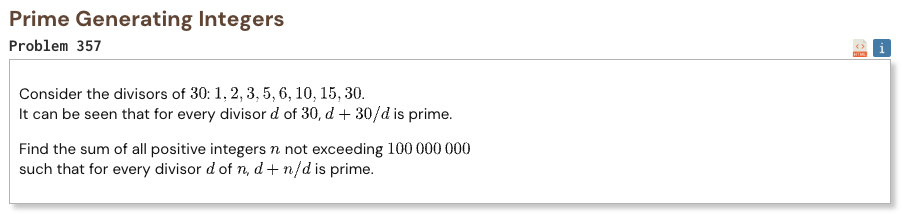

## Initial approach

* first notice that n + 1 must be prime
* this removes almost all numbers immediately
* also n must be even except for the small case n = 1
* generate primes up to the limit plus one with a sieve
* only test candidates where n + 1 is prime
* for each divisor pair, check the required prime condition
* stop early as soon as one divisor fails

In [1]:
import math

def prime_sieve(limit):
    is_prime = bytearray(b"\x01") * (limit + 1)
    is_prime[0] = 0
    is_prime[1] = 0

    for p in range(2, math.isqrt(limit) + 1):
        if is_prime[p]:
            start = p * p
            is_prime[start:limit + 1:p] = b"\x00" * (((limit - start) // p) + 1)

    return is_prime

def works(n, is_prime):
    root = math.isqrt(n)

    for d in range(1, root + 1):
        if n % d == 0:
            if not is_prime[d + n // d]:
                return False

    return True

def solve(limit):
    is_prime = prime_sieve(limit + 1)
    total = 1

    for p in range(3, limit + 2, 2):
        if is_prime[p]:
            n = p - 1

            if n <= limit and works(n, is_prime):
                total += n

    return total

In [2]:
%%time
result = solve(100_000_000)
print("Result:", result)

Result: 1739023853137
CPU times: user 10.9 s, sys: 83.2 ms, total: 11 s
Wall time: 11.1 s
